In [168]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%load_ext autoreload
%autoreload 2
from Datamodule import Datamodule
from Ensemble import Ensemble
from helpers import get_latest_run_dir, compute_uncertainties

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
LABEL_NAMES = [
    "0.T-shirt",
    "1.Trouser",
    "2.Pullover",
    "3.Dress",
    "4.Coat",
    "5.Sandal",
    "6.Shirt",
    "7.Sneaker",
    "8.Bag",
    "9.Ankle boot",
]

In [2]:
datamodule = Datamodule()
datamodule.prepare_data()
datamodule.setup("test")

In [169]:
latest_run_dir = get_latest_run_dir()

['2026-06-24 13:26:58.782422', '2026-06-24 13:41:44.486169']
Latest run: 2026-06-24 13:41:44.486169
Latest run dir: checkpoints/run_2026-06-24 13:41:44.486169


In [146]:
ensemble = Ensemble(latest_run_dir)

Model for fold=0: checkpoints/run_2026-06-24 13:41:44.486169/fold0/model-epoch=14-val_loss=0.242.ckpt
Temperature for fold=0: 1.3736447095870972
Model for fold=1: checkpoints/run_2026-06-24 13:41:44.486169/fold1/model-epoch=11-val_loss=0.239.ckpt
Temperature for fold=1: 1.0928692817687988
Model for fold=2: checkpoints/run_2026-06-24 13:41:44.486169/fold2/model-epoch=10-val_loss=0.244.ckpt
Temperature for fold=2: 1.1840633153915405
Model for fold=3: checkpoints/run_2026-06-24 13:41:44.486169/fold3/model-epoch=14-val_loss=0.232.ckpt
Temperature for fold=3: 1.2276005744934082
Model for fold=4: checkpoints/run_2026-06-24 13:41:44.486169/fold4/model-epoch=10-val_loss=0.249.ckpt
Temperature for fold=4: 1.0976569652557373


In [8]:
proba_all_before = ensemble.predict_proba_all(datamodule.X_test, scale_temperature=False)
proba_all_before = proba_all_before.detach().cpu().numpy()
proba_all_before.shape

(5, 10000, 10)

In [9]:
proba_all_after = ensemble.predict_proba_all(datamodule.X_test, scale_temperature=True)
proba_all_after = proba_all_after.detach().cpu().numpy()
proba_all_after.shape

(5, 10000, 10)

In [19]:
total_unc_before, aleatoric_unc_before, epistemic_unc_before = compute_uncertainties(proba_all_before)
total_unc_before, aleatoric_unc_before, epistemic_unc_before = total_unc_before.mean(), aleatoric_unc_before.mean(), epistemic_unc_before.mean()
total_unc_after, aleatoric_unc_after, epistemic_unc_after = compute_uncertainties(proba_all_after)
total_unc_after, aleatoric_unc_after, epistemic_unc_after = total_unc_after.mean(), aleatoric_unc_after.mean(), epistemic_unc_after.mean()

pd.DataFrame([
    [total_unc_before, total_unc_after, (total_unc_after-total_unc_before)/total_unc_before],
    [aleatoric_unc_before, aleatoric_unc_after, (aleatoric_unc_after-aleatoric_unc_before)/aleatoric_unc_before],
    [epistemic_unc_before, epistemic_unc_after, (epistemic_unc_after-epistemic_unc_before)/epistemic_unc_before],
], index=["total", "aleatoric", "epistemic"], columns=["before", "after", "relative_change"])

,before,after,relative_change
total,0.309520,0.370500,0.197013
aleatoric,0.262033,0.327938,0.251515
epistemic,0.047487,0.042562,-0.103723


In [30]:
total_unc, aleatoric_unc, epistemic_unc = compute_uncertainties(proba_all_after)
total_unc = pd.DataFrame(total_unc, columns=["total_uncertainty"])
total_unc = total_unc.sort_values(by=total_unc.columns[0])
total_unc

,total_uncertainty
5545,4.856493e-07
8102,7.074677e-07
2677,1.037876e-06
8959,1.186125e-06
26,1.547531e-06
...,...
9682,2.507658e+00
9847,2.540473e+00
79,2.558601e+00
7793,2.653194e+00


In [39]:
proba_all_after.shape

(5, 10000, 10)

In [141]:
def display_imgs_for_uncertainty(uncertainty: pd.DataFrame) -> None:
    cols = int(np.ceil(np.sqrt(uncertainty.shape[0])))
    rows = int(np.ceil(uncertainty.shape[0] / cols))
    print(f"{rows=} {cols=}")
    fig, axs = plt.subplots(rows, cols, figsize=(14, 14))
    axs = axs.flatten()

    imgs = datamodule.X_test[uncertainty.index]
    y_pred = ensemble(imgs)
    y_true = datamodule.y_test[uncertainty.index]

    accuracy = (y_pred == y_true).sum().item() / y_pred.shape[0]
    print(f"{accuracy=}")

    for idx in range(imgs.shape[0]):
        ax = axs[idx]
        ax.imshow(imgs[idx].reshape(28, 28), cmap="gray")
        ax.axis("off")

        if y_pred[idx] == y_true[idx]:
            ax.set_title(LABEL_NAMES[y_true[idx]])
        else:
            ax.set_title(LABEL_NAMES[y_pred[idx]] + "/" + LABEL_NAMES[y_true[idx]])
            ax.title.set_color("tab:red")

    plt.tight_layout()
    plt.show()

    labels = datamodule.y_test[uncertainty.index].numpy()
    sns.countplot(x=labels, order=range(len(LABEL_NAMES)))
    plt.show()

rows=10 cols=10
accuracy=1.0


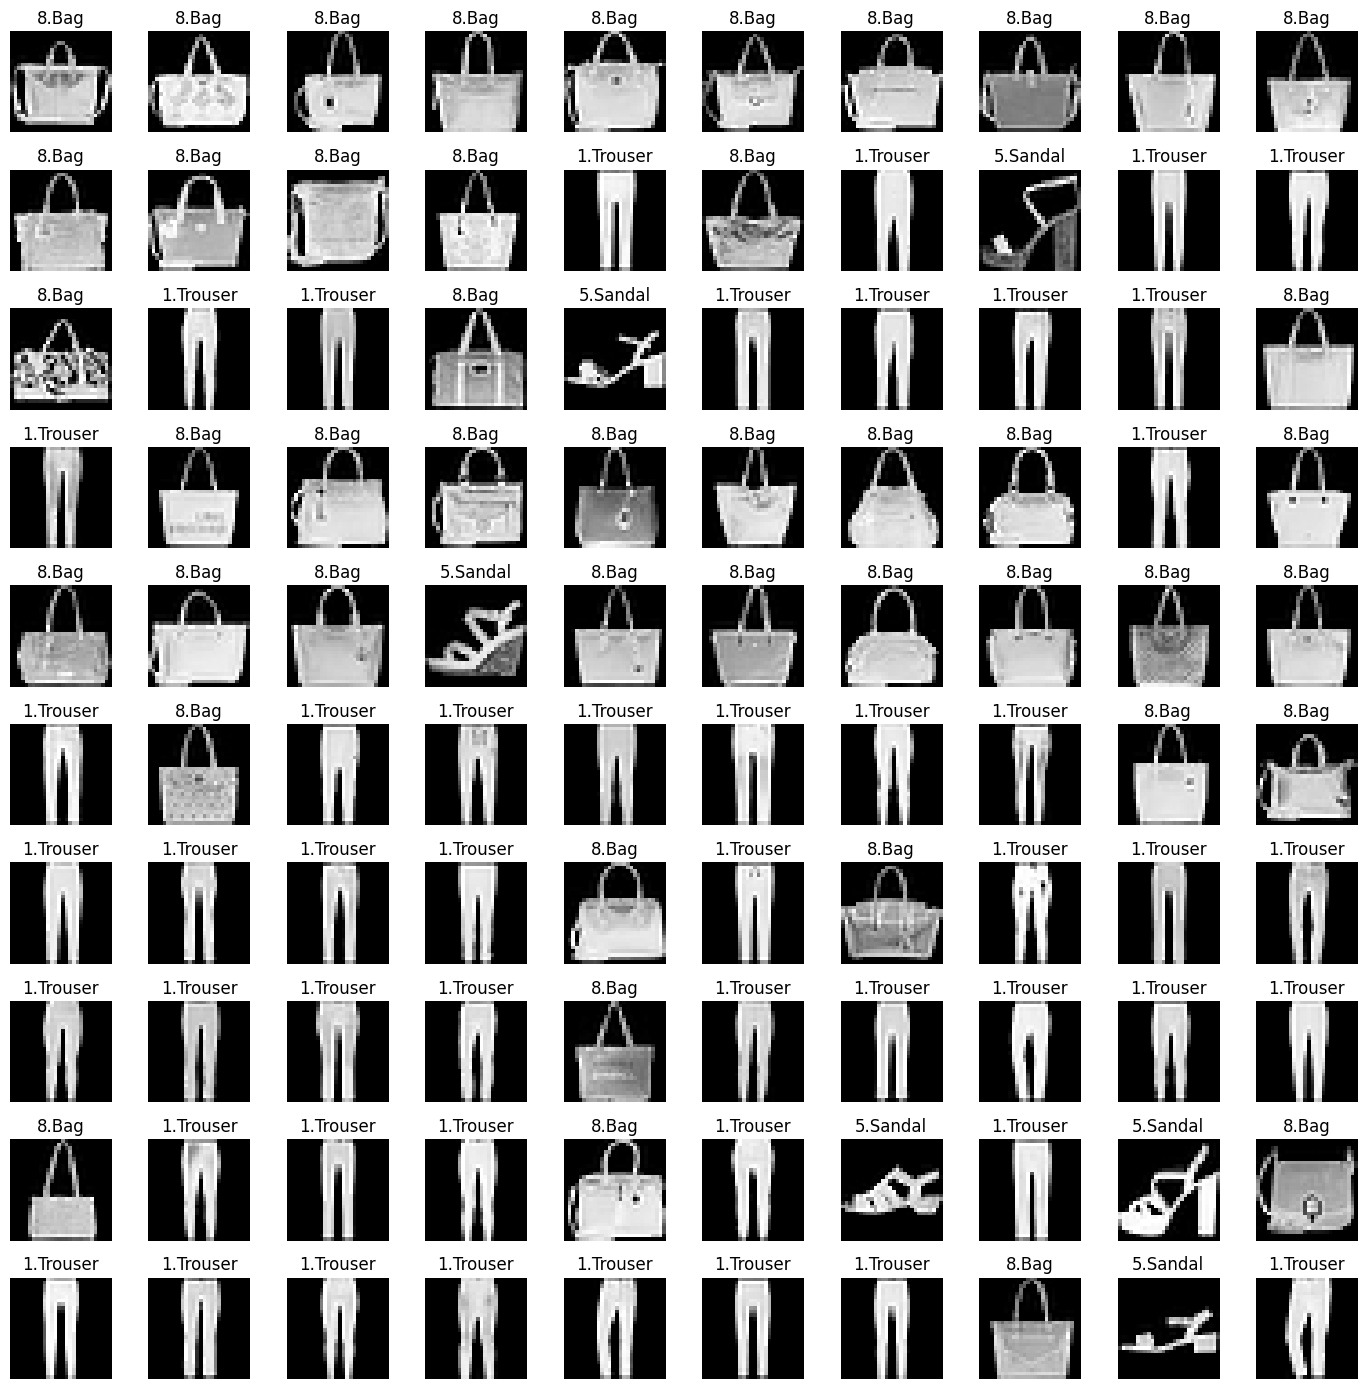

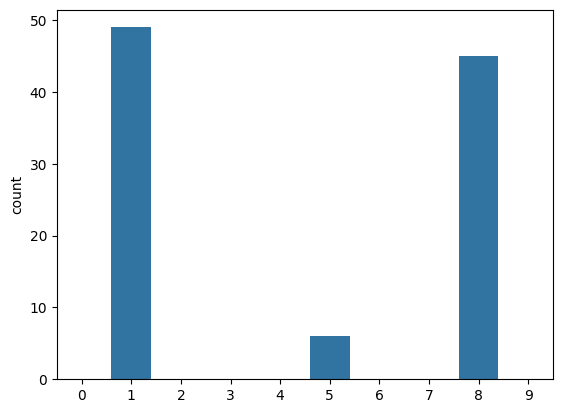

In [142]:
most_certain = total_unc.iloc[:100]
display_imgs_for_uncertainty(most_certain)

rows=10 cols=10
accuracy=0.37


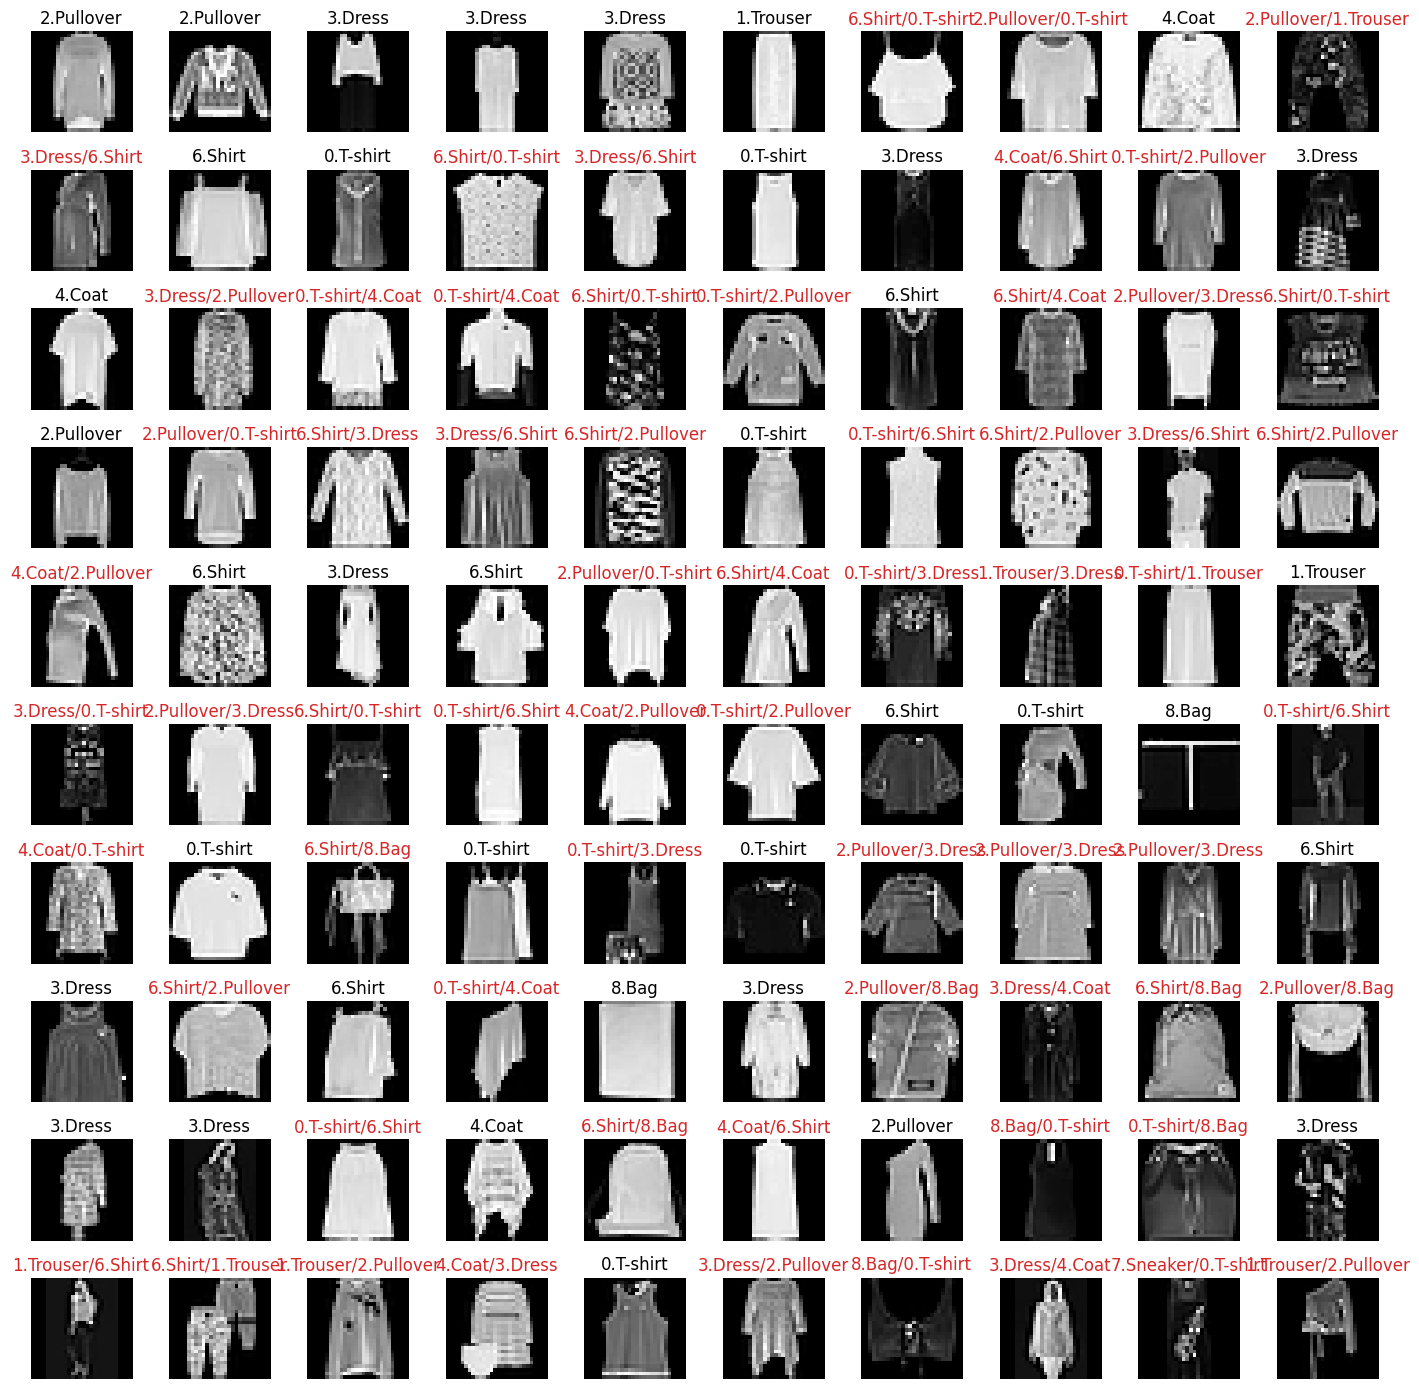

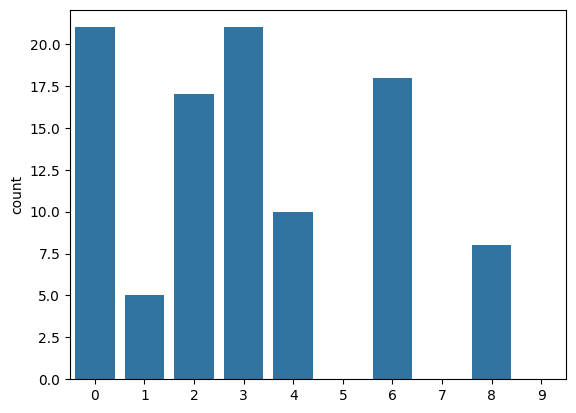

In [144]:
least_certain = total_unc.iloc[-100:]
display_imgs_for_uncertainty(least_certain)

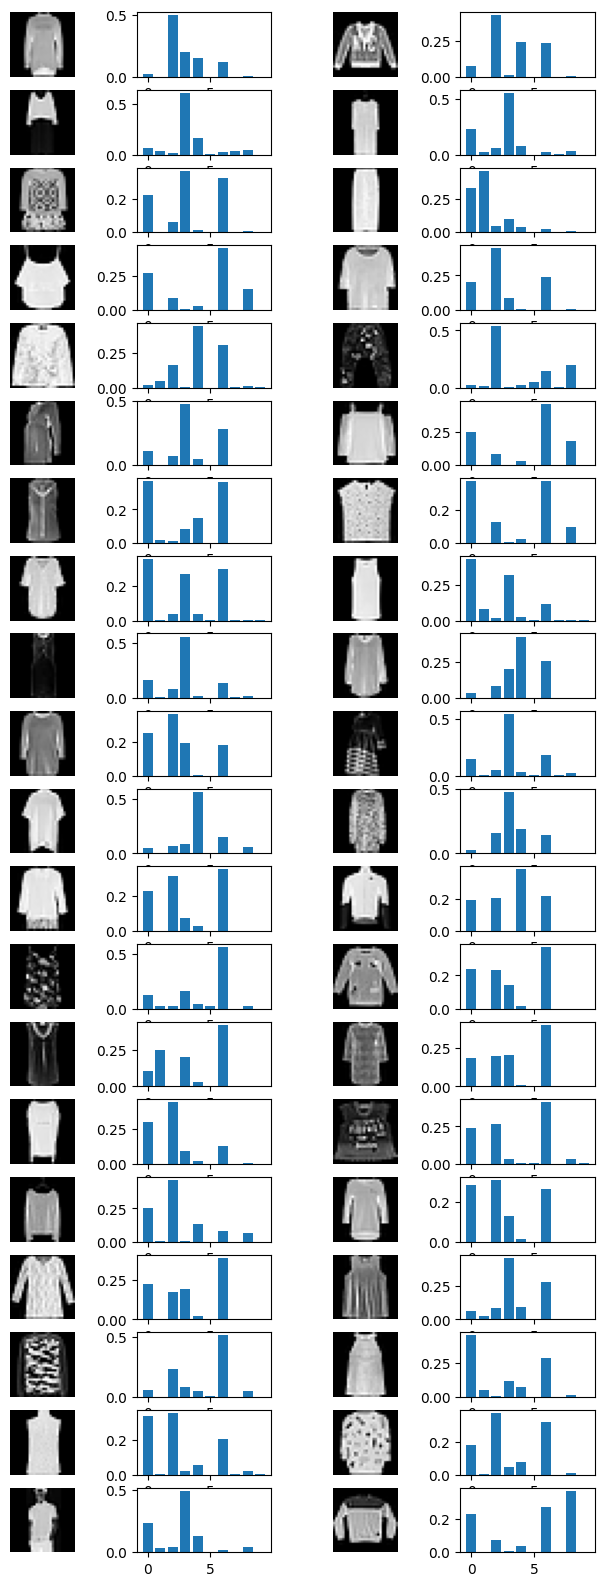

In [166]:
fig, axs = plt.subplots(20, 4, figsize=(8, 20))
axs = axs.reshape(-1, 2)

imgs = datamodule.X_test[least_certain.index]
proba = ensemble.predict_proba(imgs)
proba = proba.detach().numpy()
y_true = datamodule.y_test[least_certain.index]

for i in range(axs.shape[0]):
    axs[i, 0].imshow(imgs[i].reshape(28, 28), cmap="gray")
    axs[i, 0].axis("off")
    axs[i, 1].bar(range(10), proba[i])

plt.show()